TensorFlow Version: 2.21.0
Dataset downloaded successfully!
Dataset extracted successfully!
Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Classes: ['cats', 'dogs']


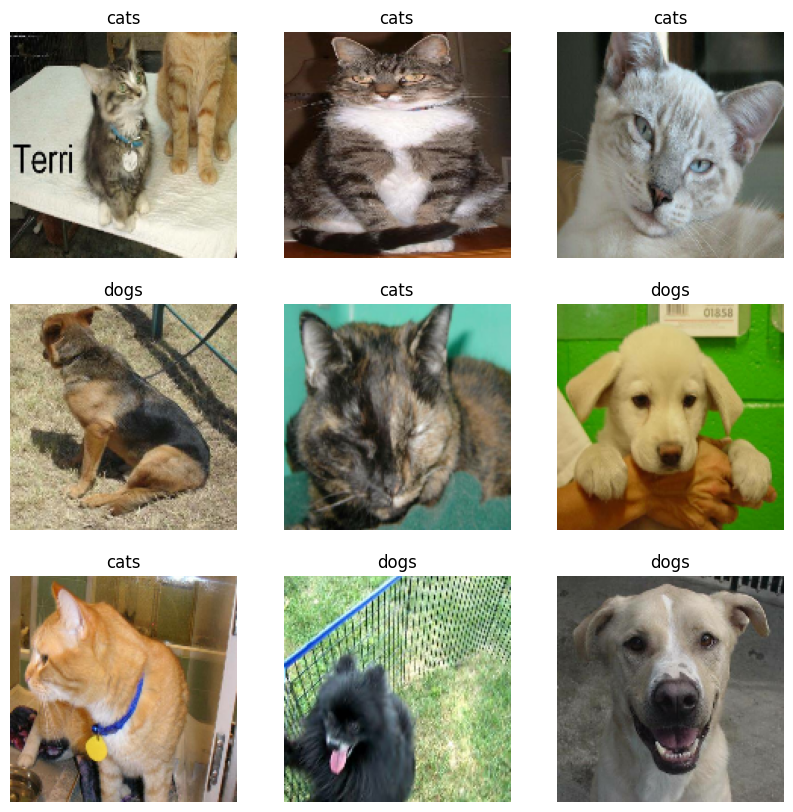


CNN MODEL SUMMARY


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training CNN model...
Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 19s 160ms/step - accuracy: 0.5145 - loss: 0.7102 - val_accuracy: 0.5170 - val_loss: 0.6876
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.5915 - loss: 0.6714 - val_accuracy: 0.5430 - val_loss: 0.6756
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.6380 - loss: 0.6343 - val_accuracy: 0.6020 - val_loss: 0.6629
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.6850 - loss: 0.5975 - val_accuracy: 0.6460 - val_loss: 0.6399
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.7225 - loss: 0.5487 - val_accuracy: 0.6580 - val_loss: 0.6320
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.6580 - loss: 0.6320

CNN MODEL RESULT
Validation Accuracy: 65.8 %


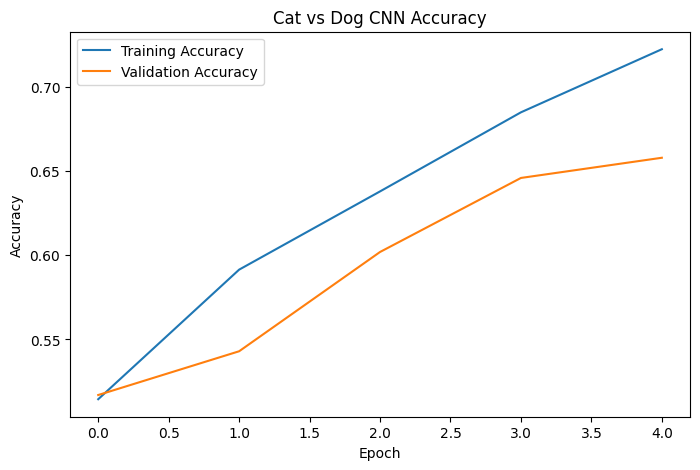

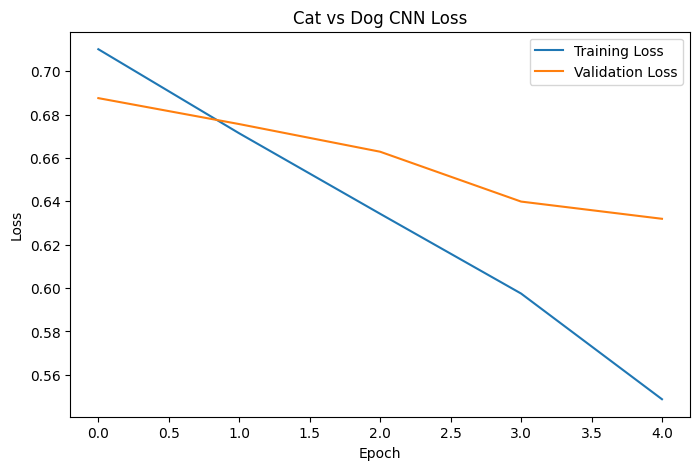


Upload a CAT or DOG image:


Saving dog.jfif to dog.jfif


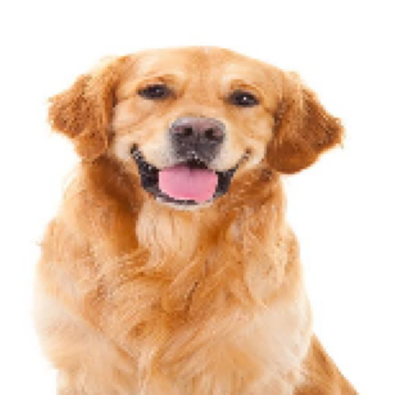


PREDICTION RESULT
🐶 DOG
Confidence: 52.92 %


In [ ]:
# ============================================
# CNN FOR CAT AND DOG IMAGE CLASSIFICATION
# ============================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import zipfile

print("TensorFlow Version:", tf.__version__)

# ============================================
# 1. DOWNLOAD DATASET
# ============================================

url = "https://storage.googleapis.com/tensorflow-1-public/course2/cats_and_dogs_filtered.zip"

zip_path = "/content/cats_and_dogs_filtered.zip"

print("Downloading dataset...")

!wget -q "$url" -O "$zip_path"

print("Dataset downloaded successfully!")

# ============================================
# 2. EXTRACT DATASET
# ============================================

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content/")

print("Dataset extracted successfully!")

# ============================================
# 3. DATASET PATH
# ============================================

dataset_path = "/content/cats_and_dogs_filtered"

train_dir = os.path.join(
    dataset_path, "train"
)

validation_dir = os.path.join(
    dataset_path, "validation"
)

# ============================================
# 4. LOAD DATASET
# ============================================

IMG_SIZE = (150, 150)
BATCH_SIZE = 32

train_data = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

validation_data = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Classes:", train_data.class_names)

# ============================================
# 5. DISPLAY SAMPLE IMAGES
# ============================================

plt.figure(figsize=(10, 10))

for images, labels in train_data.take(1):

    for i in range(9):

        plt.subplot(3, 3, i + 1)

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        plt.title(
            train_data.class_names[
                labels[i]
            ]
        )

        plt.axis("off")

plt.show()

# ============================================
# 6. CREATE CNN MODEL
# ============================================

model = tf.keras.Sequential([

    # Normalize pixel values
    tf.keras.layers.Rescaling(1./255),

    # Convolution Layer 1
    tf.keras.layers.Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(
        2, 2
    ),

    # Convolution Layer 2
    tf.keras.layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(
        2, 2
    ),

    # Convolution Layer 3
    tf.keras.layers.Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(
        2, 2
    ),

    # Flatten
    tf.keras.layers.Flatten(),

    # Fully Connected Layer
    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    # Dropout
    tf.keras.layers.Dropout(0.5),

    # Output
    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

# ============================================
# 7. COMPILE MODEL
# ============================================

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("\nCNN MODEL SUMMARY")
model.summary()

# ============================================
# 8. TRAIN MODEL
# ============================================

print("\nTraining CNN model...")

history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=5
)

# ============================================
# 9. EVALUATE MODEL
# ============================================

loss, accuracy = model.evaluate(
    validation_data
)

print("\n==============================")
print("CNN MODEL RESULT")
print("==============================")

print(
    "Validation Accuracy:",
    round(accuracy * 100, 2),
    "%"
)

# ============================================
# 10. ACCURACY GRAPH
# ============================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Cat vs Dog CNN Accuracy"
)

plt.legend()

plt.show()

# ============================================
# 11. LOSS GRAPH
# ============================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Cat vs Dog CNN Loss"
)

plt.legend()

plt.show()

# ============================================
# 12. UPLOAD TEST IMAGE
# ============================================

from google.colab import files

print("\nUpload a CAT or DOG image:")

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

# ============================================
# 13. LOAD IMAGE
# ============================================

image = tf.keras.utils.load_img(
    image_path,
    target_size=IMG_SIZE
)

plt.figure(figsize=(5, 5))

plt.imshow(image)

plt.axis("off")

plt.show()

# ============================================
# 14. PREPARE IMAGE
# ============================================

image_array = tf.keras.utils.img_to_array(
    image
)

image_array = np.expand_dims(
    image_array,
    axis=0
)

# ============================================
# 15. PREDICT
# ============================================

prediction = model.predict(
    image_array,
    verbose=0
)[0][0]

print("\n==============================")
print("PREDICTION RESULT")
print("==============================")

if prediction < 0.5:

    confidence = (1 - prediction) * 100

    print("🐱 CAT")

    print(
        "Confidence:",
        round(confidence, 2),
        "%"
    )

else:

    confidence = prediction * 100

    print("🐶 DOG")

    print(
        "Confidence:",
        round(confidence, 2),
        "%"
    )